In [1]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)

# ==============================
# SETTINGS
# ==============================
num_loans = 10000
months = pd.date_range("2024-01-01", periods=12, freq="MS")

channels = ["Retail", "Wholesale", "Correspondent", "Direct"]
products = ["30yr Fixed", "15yr Fixed", "ARM 5/1"]
states = ["CA", "TX", "FL", "NY", "IL", "AZ"]

# ==============================
# 1️⃣ FUNDED LOANS (10,000 rows)
# ==============================
loans = []

for i in range(num_loans):
    month = random.choice(months)
    loans.append({
        "loan_id": f"LN-2024-{i+1:05d}",
        "channel": random.choice(channels),
        "product": random.choice(products),
        "funded_amount": random.randint(150000, 1200000),
        "funded_month": month,
        "margin_bps": random.randint(250, 380),
        "interest_rate": round(random.uniform(5.5, 8.5), 3),
        "state": random.choice(states)
    })

funded_loans_df = pd.DataFrame(loans)
funded_loans_df.to_csv("funded_loans.csv", index=False)

print("✅ funded_loans.csv created:", len(funded_loans_df), "rows")


# ==============================
# 2️⃣ COST ALLOCATION (36 rows)
# ==============================
cost_centers = ["ORIGINATION", "SECONDARY", "IT"]
cost_data = []

for month in months:
    for center in cost_centers:
        cost_data.append({
            "cost_center": center,
            "cost_month": month,
            "fixed_cost": random.randint(80000, 400000),
            "variable_cost": random.randint(20000, 150000),
            "headcount": random.randint(8, 60)
        })

cost_df = pd.DataFrame(cost_data)
cost_df.to_csv("cost_allocation.csv", index=False)

print("✅ cost_allocation.csv created:", len(cost_df), "rows")


# ==============================
# 3️⃣ LOCK PIPELINE (12,000 rows)
# ==============================
locks = []

for i in range(12000):
    month = random.choice(months)
    funded_flag = np.random.choice([0,1], p=[0.3,0.7])  # 70% funded

    locks.append({
        "lock_id": f"LOCK-2024-{i+1:05d}",
        "channel": random.choice(channels),
        "lock_month": month,
        "locked_amount": random.randint(150000, 1200000),
        "funded_flag": funded_flag
    })

lock_df = pd.DataFrame(locks)
lock_df.to_csv("lock_pipeline.csv", index=False)

print("✅ lock_pipeline.csv created:", len(lock_df), "rows")


# ==============================
# 4️⃣ GENERAL LEDGER (60 rows)
# ==============================
gl_accounts = ["Interest Income", "Origination Fees", "Salaries", "Technology", "Marketing"]

categories = {
    "Interest Income": "Revenue",
    "Origination Fees": "Revenue",
    "Salaries": "Expense",
    "Technology": "Expense",
    "Marketing": "Expense"
}

gl_data = []

for month in months:
    for acc in gl_accounts:
        gl_data.append({
            "gl_account": acc,
            "gl_month": month,
            "amount": random.randint(50000, 800000),
            "category": categories[acc]
        })

gl_df = pd.DataFrame(gl_data)
gl_df.to_csv("general_ledger.csv", index=False)

print("✅ general_ledger.csv created:", len(gl_df), "rows")


print("\n🎉 ALL DATASETS GENERATED SUCCESSFULLY!")

✅ funded_loans.csv created: 10000 rows
✅ cost_allocation.csv created: 36 rows
✅ lock_pipeline.csv created: 12000 rows
✅ general_ledger.csv created: 60 rows

🎉 ALL DATASETS GENERATED SUCCESSFULLY!


In [2]:
funded_loans_df.head()

,loan_id,channel,product,funded_amount,funded_month,margin_bps,interest_rate,state
0,LN-2024-00001,Retail,ARM 5/1,464603,2024-01-01,284,6.749,AZ
1,LN-2024-00002,Retail,ARM 5/1,506179,2024-06-01,342,6.061,NY
2,LN-2024-00003,Retail,ARM 5/1,436148,2024-11-01,339,8.338,AZ
3,LN-2024-00004,Correspondent,15yr Fixed,971030,2024-05-01,269,6.934,AZ
4,LN-2024-00005,Wholesale,ARM 5/1,255944,2024-08-01,292,7.218,IL


In [3]:
funded_loans_df.describe()

,funded_amount,funded_month,margin_bps,interest_rate
count,1.000000e+04,10000,10000.00000,10000.000000
mean,6.710819e+05,2024-06-18 02:26:09.600000,314.48800,6.983860
min,1.500160e+05,2024-01-01 00:00:00,250.00000,5.500000
25%,4.102198e+05,2024-04-01 00:00:00,282.00000,6.234750
50%,6.623810e+05,2024-07-01 00:00:00,314.00000,6.972500
75%,9.328158e+05,2024-10-01 00:00:00,347.00000,7.728000
max,1.199928e+06,2024-12-01 00:00:00,380.00000,8.500000
std,3.037927e+05,NaN,37.75292,0.862115


In [4]:
funded_loans_df.shape

(10000, 8)

In [5]:
funded_loans_df.dtypes

loan_id                  object
channel                  object
product                  object
funded_amount             int64
funded_month     datetime64[ns]
margin_bps                int64
interest_rate           float64
state                    object
dtype: object

In [6]:
funded_loans_df.isnull().sum()

loan_id          0
channel          0
product          0
funded_amount    0
funded_month     0
margin_bps       0
interest_rate    0
state            0
dtype: int64

In [7]:
funded_loans_df.duplicated().sum()

np.int64(0)

In [8]:
total_loans = funded_loans_df['loan_id'].count()
total_volume = funded_loans_df['funded_amount'].sum()
avg_loan_size = funded_loans_df['funded_amount'].mean()
avg_margin = funded_loans_df['margin_bps'].mean()

print("Total Loans:", total_loans)
print("Total Volume: $", round(total_volume,2))
print("Average Loan Size: $", round(avg_loan_size,2))
print("Average Margin (bps):", round(avg_margin,2))

Total Loans: 10000
Total Volume: $ 6710819223
Average Loan Size: $ 671081.92
Average Margin (bps): 314.49


In [9]:
monthly_summary = funded_loans_df.groupby('funded_month').agg(
    total_volume=('funded_amount','sum'),
    loan_count=('loan_id','count'),
    avg_margin=('margin_bps','mean')
).reset_index()

monthly_summary.head()

,funded_month,total_volume,loan_count,avg_margin
0,2024-01-01,541264322,797,315.321205
1,2024-02-01,560516868,807,313.078067
2,2024-03-01,541944358,816,314.392157
3,2024-04-01,553947606,849,314.188457
4,2024-05-01,549344986,835,315.098204


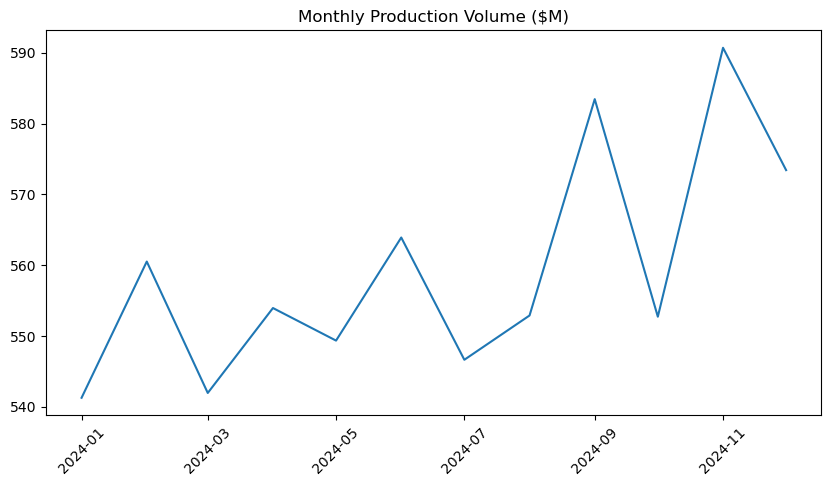

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_summary['funded_month'], monthly_summary['total_volume']/1e6)
plt.title("Monthly Production Volume ($M)")
plt.xticks(rotation=45)
plt.show()